# Pure H2 Surface Tension — SR Pipeline

| Step | Script | Produces |
|------|--------|---------|
| **1 — Run Part 1 below** | `Pure_component.ipynb` | `pure_component_results.csv` |
| **2 — Run in terminal** | `julia --threads auto H2.jl` | `outputs/hall_of_fame_gamma.jls` + timestamped CSV |
| **3 — Run Part 2 below** | `Pure_component.ipynb` | choose equation → comparison plot |

---
## Part 1 — Generate PC-SAFT + cDFT Data

In [1]:
import time
notebook_start = time.perf_counter()
# %pip install -e /home/darshan/A6/PCSAFT_cDFT/thermoift

import thermoift.semi_emperical_correlations as SEC
import thermoift.PLOT_SETTINGS as ps
import numpy as np, matplotlib.pyplot as plt
import json, pathlib, thermoift
import pandas as pd
import glob, re
import sys
sys.path.insert(0, '/home/darshan/A6/PCSAFT_cDFT/Interfacethermopy/src')
from Interfacethermopy.Interfacethermopy import InterfacialTension
import feos
import si_units as si
from matplotlib.lines import Line2D

In [2]:
_records = json.loads((pathlib.Path(thermoift.__file__).parent / "parameters.json").read_text())

_hdr = f"{'Component':<20} {'m':>8} {'sigma(A)':>10} {'eps/k(K)':>10} {'q':>8} {'mu':>8}"
print("PC-SAFT / PCP-SAFT parameters loaded by SEC")
print(_hdr)
print("-" * len(_hdr))
for r in _records:
    name = r["identifier"]["name"]
    print(
        f"{name:<20}"
        f" {str(r.get('m',         '--')):>8}"
        f" {str(r.get('sigma',     '--')):>10}"
        f" {str(r.get('epsilon_k', '--')):>10}"
        f" {str(r.get('q',         '--')):>8}"
        f" {str(r.get('mu',        '--')):>8}"
    )

PC-SAFT / PCP-SAFT parameters loaded by SEC
Component                   m   sigma(A)   eps/k(K)        q       mu
---------------------------------------------------------------------
carbon dioxide         1.6298     3.0867     163.34   3.9546       --
hydrogen                 0.68       3.54      31.57       --       --
nitrogen               1.1879     3.3353      90.99   1.1151       --
argon                     1.0    3.37751  117.80903       --       --
methane                   1.0    3.70051  150.07147       --       --
oxygen                1.14702    3.17933  113.62724       --       --
carbon monoxide       1.32286    3.24532   91.17087       --       --
hydrogen sulfide        1.333      3.332     235.54    2.938    0.978


In [3]:
# SAFT-VRQ Mie (SAFT-VRQ Mie) parameters for H2 — Aasen et al. 2019 (FH1)
# Reference: Aasen et al., J. Chem. Phys. 151, 064508 (2019)
print('='*55)
print('SAFT-VRQ Mie (FH1) parameters for H2  [Aasen 2019]')
print('='*55)
print(f"  m         = 1.0")
print(f"  sigma     = 3.0243  Angstrom")
print(f"  epsilon/k = 26.706  K")
print(f"  lambda_r  = 9.0     (repulsive exponent)")
print(f"  lambda_a  = 6.0     (attractive exponent)")
print(f"  fh        = 2       (1st-order Feynman-Hibbs)")
print(f"  Tc (SAFT-VRQ Mie) = 33.303 K   [exp: 33.145 K]")
print(f"  Tc (PCP-SAFT)   = 48.074 K   [overestimate — no quantum correction]")
print('='*55)


SAFT-VRQ Mie (FH1) parameters for H2  [Aasen 2019]
  m         = 1.0
  sigma     = 3.0243  Angstrom
  epsilon/k = 26.706  K
  lambda_r  = 9.0     (repulsive exponent)
  lambda_a  = 6.0     (attractive exponent)
  fh        = 2       (1st-order Feynman-Hibbs)
  Tc (SAFT-VRQ Mie) = 33.303 K   [exp: 33.145 K]
  Tc (PCP-SAFT)   = 48.074 K   [overestimate — no quantum correction]


In [4]:
# SAFT-VRQ Mie (Aasen 2019 FH1) parameters for H2
# m=1.0, sigma=2.9195 A, eps/k=55.729 K, lr=20, la=6, fh=2
# Gives Tc = 33.433 K (exp: 33.145 K) vs PCP-SAFT Tc = 48.07 K

SAFTQR_PARAMS = dict(m=1.0, sigma=2.9195, epsilon_k=55.729, lr=20.0, la=6.0, fh=2)
SAFTQR_MW     = 2.01568   # g/mol
T_vals = np.arange(15.0, 32.8, 0.5)   # 0.5 K resolution; or run generate_data_saftqrmie.py

force_recompute = False  # set True to regenerate even if CSV exists

if not force_recompute and pathlib.Path('pure_component_results.csv').exists():
    print('Loading existing pure_component_results.csv ...')
    df = pd.read_csv('pure_component_results.csv')
else:
    _rec = feos.PureRecord(
        feos.Identifier(name='hydrogen'),
        molarweight=SAFTQR_MW,
        **SAFTQR_PARAMS
    )
    _params  = feos.Parameters.from_records([_rec])
    _func    = feos.HelmholtzEnergyFunctional.saftvrqmie(_params)
    _eosTh   = feos.EquationOfState.saftvrqmie(_params)
    _cp      = feos.State.critical_point(_eosTh)
    Tc_si    = _cp.temperature
    Tc_K     = float(str(Tc_si).split()[0])
    Pc_bar   = float(_cp.pressure() / si.BAR)

    rows = []
    for T_K in T_vals:
        try:
            vle   = feos.PhaseEquilibrium.pure(_func, float(T_K) * si.KELVIN)
            iface = feos.PlanarInterface.from_tanh(
                vle=vle, n_grid=1024,
                l_grid=200.0 * si.ANGSTROM, critical_temperature=Tc_si)
            iface.solve()
            gamma = float(iface.surface_tension * 1e3 / si.NEWTON * si.METER)
            rhoL  = float(str(vle.liquid.density).split()[0])
            rhoV  = float(str(vle.vapor.density).split()[0])
            Psat  = float(vle.liquid.pressure() / si.BAR)
            rows.append((T_K, gamma, rhoL, rhoV, Tc_K, Pc_bar, Psat))
        except Exception as e:
            print(f'  T={T_K} K skipped: {e}')

    df = pd.DataFrame(rows, columns=['T_K', 'gamma', 'rhoL', 'rhoV', 'Tc', 'Pc', 'Psat'])
    df.to_csv('pure_component_results.csv', index=False)
    print(f'Saved {len(df)} rows to pure_component_results.csv')

print(df.head())
print(f'Tc (SAFT-VRQ Mie) = {df["Tc"].iloc[0]:.3f} K')

# ── Also load/compute PCP-SAFT data for comparison ────────────────────────
force_recompute_pcsaft = False

if not force_recompute_pcsaft and pathlib.Path('pcsaft_comparison_results.csv').exists():
    print('Loading existing pcsaft_comparison_results.csv ...')
    df_pcsaft = pd.read_csv('pcsaft_comparison_results.csv')
else:
    model = SEC.semi_emperical_correlations()
    rows_pc = []
    for T_K in np.arange(15.0, 64.0, 0.5):   # 0.5 K resolution
        gamma0, rhoL0, rhoV0, Tc, Pc, Psat = model._pure_component_cDFT('hydrogen', float(T_K))
        if np.isnan(gamma0):
            continue
        rows_pc.append((T_K, gamma0, rhoL0, rhoV0, Tc, Pc, Psat))
    df_pcsaft = pd.DataFrame(rows_pc, columns=['T_K', 'gamma', 'rhoL', 'rhoV', 'Tc', 'Pc', 'Psat'])
    df_pcsaft.to_csv('pcsaft_comparison_results.csv', index=False)
    print(f'PCP-SAFT: Saved {len(df_pcsaft)} rows')

print(f'PCP-SAFT Tc = {df_pcsaft["Tc"].iloc[0]:.3f} K')


Loading existing pure_component_results.csv ...
    T_K     gamma       rhoL        rhoV         Tc         Pc      Psat
0  16.5  2.970894  36.427209  150.644265  33.432617  13.840876  0.201075
1  17.0  2.860350  36.264307  187.614214  33.432617  13.840876  0.256648
2  17.5  2.750878  36.089691  230.469298  33.432617  13.840876  0.322653
3  18.0  2.642418  35.903418  279.659408  33.432617  13.840876  0.400134
4  18.5  2.534928  35.705518  335.634953  33.432617  13.840876  0.490136
Tc (SAFT-VRQ Mie) = 33.433 K
Loading existing pcsaft_comparison_results.csv ...
PCP-SAFT Tc = 48.075 K


In [5]:
_tc = float(df["Tc"].iloc[0])
_pc = float(df["Pc"].iloc[0])

_crit_files = [
    pathlib.Path("../component_Tc.json"),
    pathlib.Path("../../../PART_1/RESIDUAL/SR/Pure_fluid/component_Tc.json"),
]

for _p in _crit_files:
    _crit    = json.loads(_p.read_text())
    _old_tc  = _crit["hydrogen"]["Tc"]
    _old_pc  = _crit["hydrogen"]["Pc"]
    _crit["hydrogen"]["Tc"] = _tc
    _crit["hydrogen"]["Pc"] = _pc
    _p.write_text(json.dumps(_crit, indent=4))
    print(f"{_p}")
    print(f"  Tc: {_old_tc:.6f}  ->  {_tc:.6f} K")
    print(f"  Pc: {_old_pc:.6f}  ->  {_pc:.6f} bar")

../component_Tc.json
  Tc: 33.432617  ->  33.432617 K
  Pc: 13.840876  ->  13.840876 bar
../../../PART_1/RESIDUAL/SR/Pure_fluid/component_Tc.json
  Tc: 33.432617  ->  33.432617 K
  Pc: 13.840876  ->  13.840876 bar


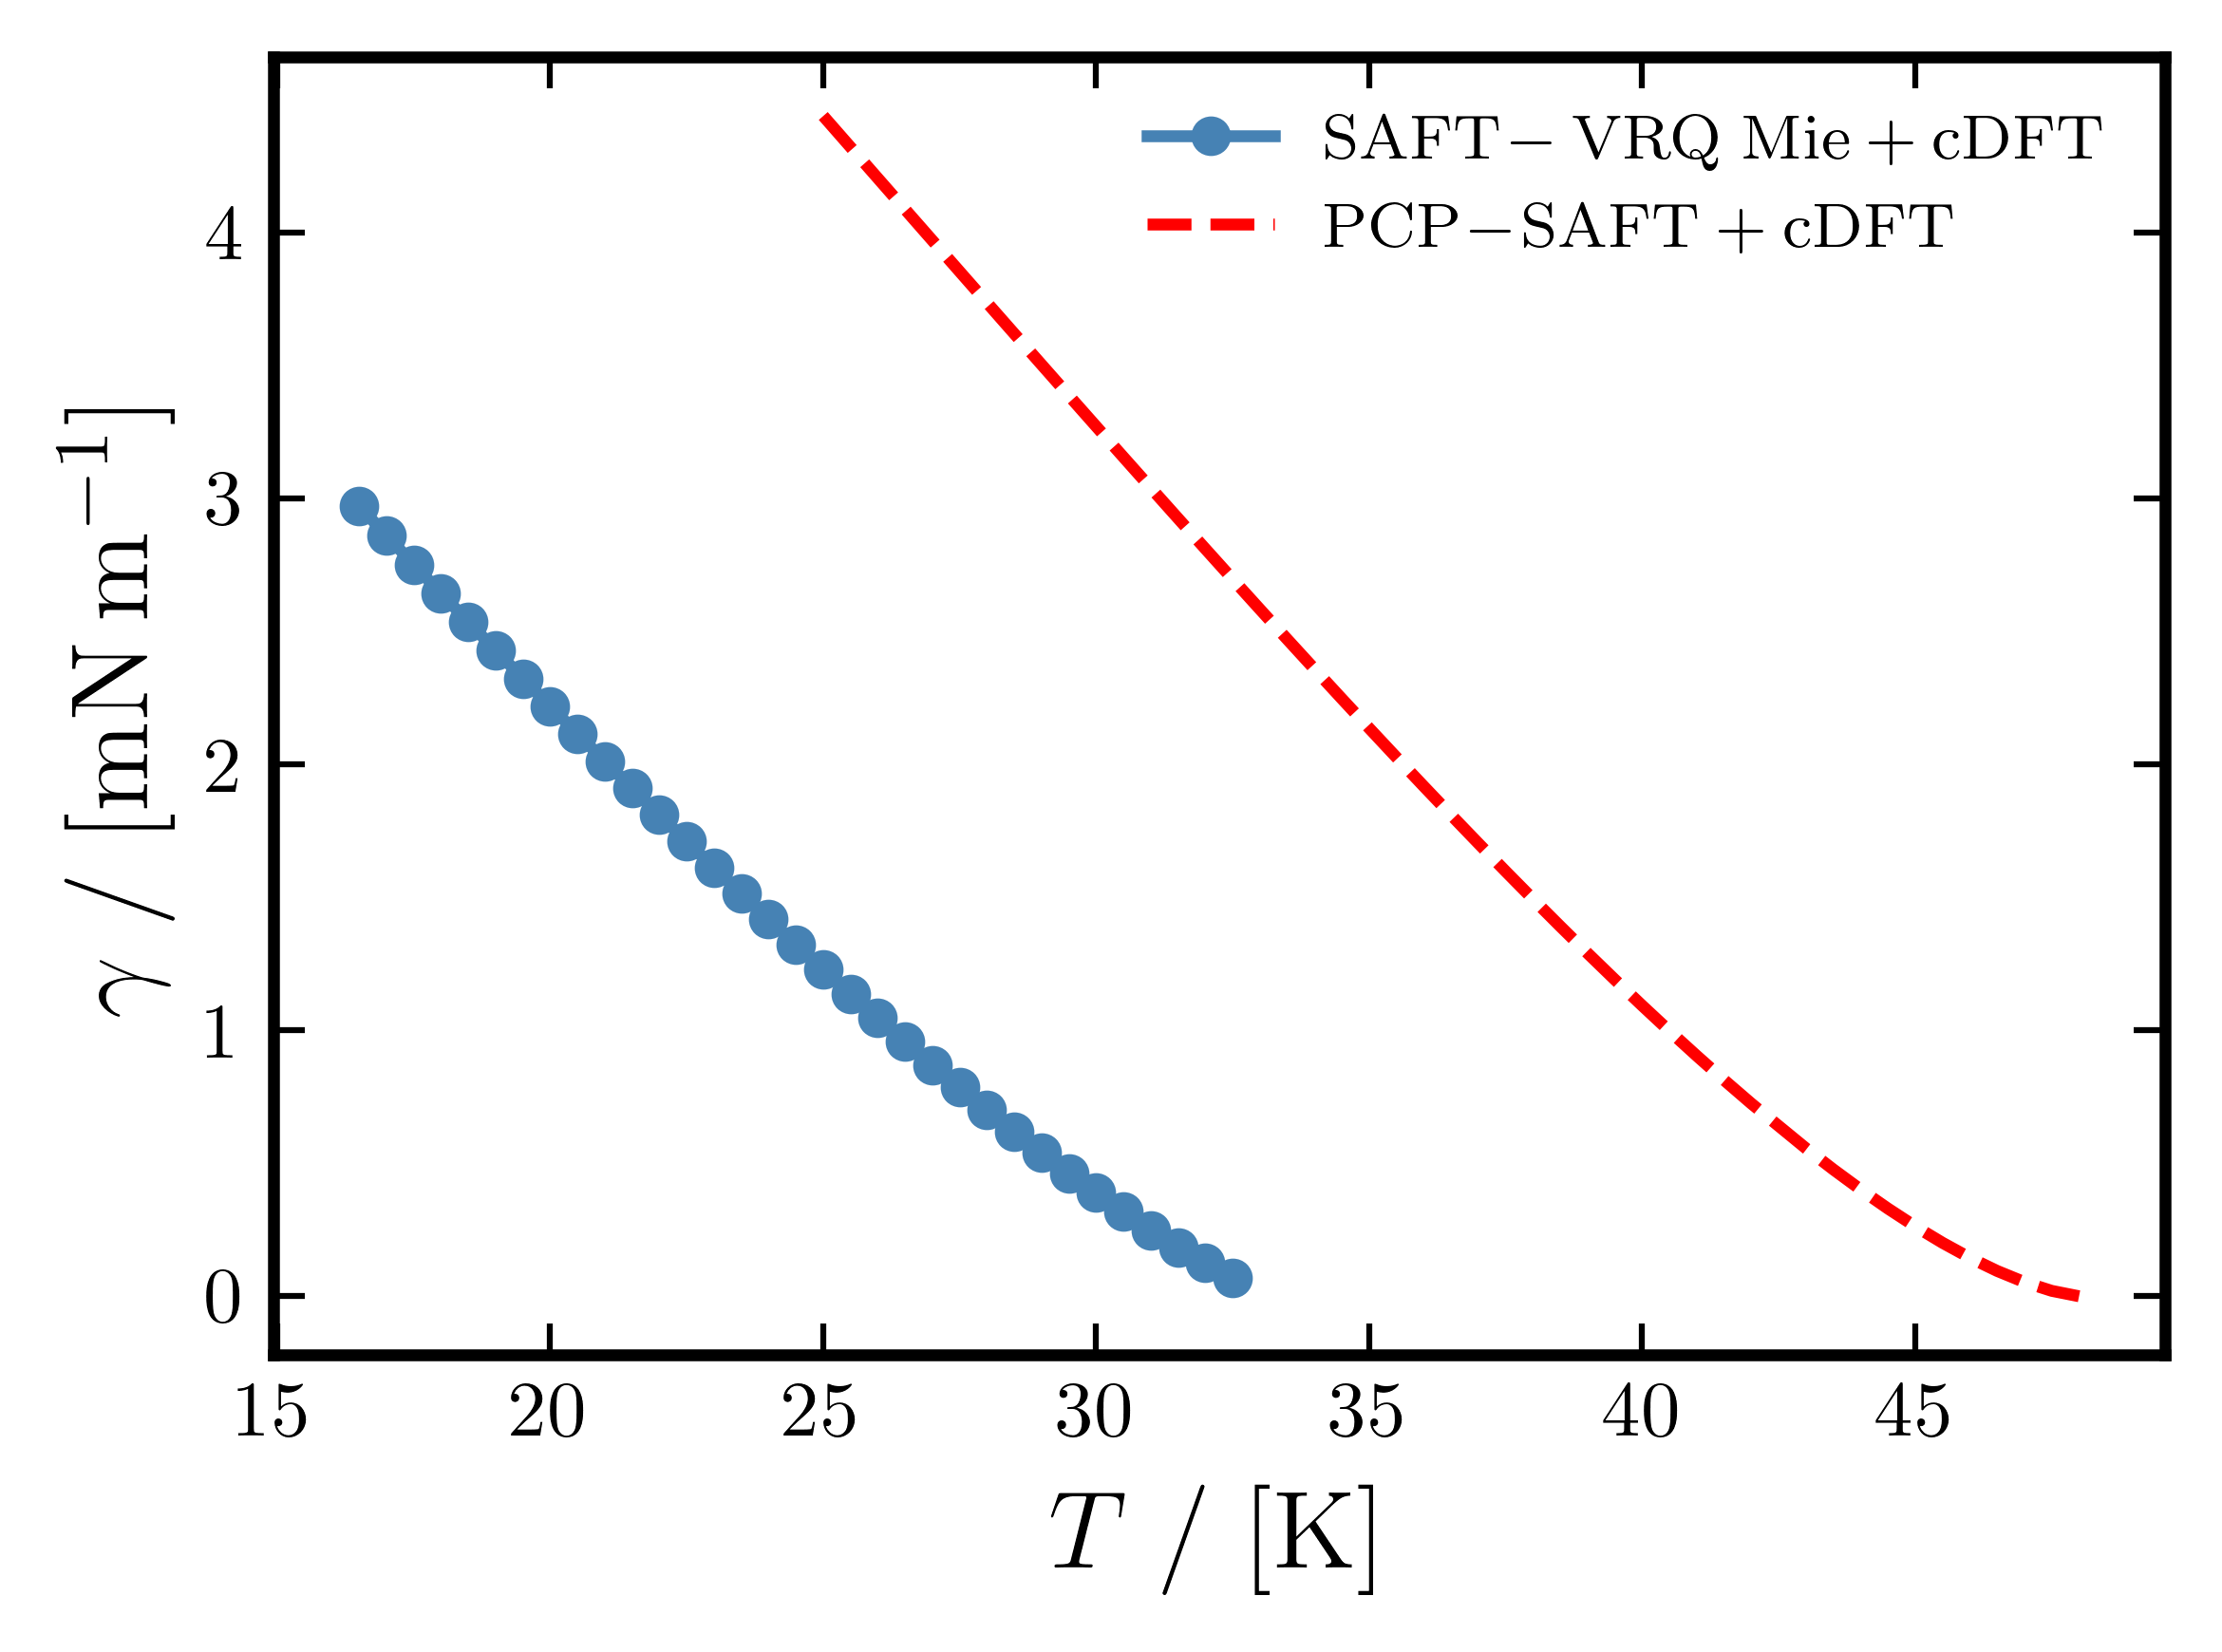

In [6]:
fig, ax = ps.plot_init()
ax.plot(df['T_K'], df['gamma'], 'o-', markersize=4, color='steelblue',
        label=r'$\mathrm{SAFT\!-VRQ\;Mie+cDFT}$')
ax.plot(df_pcsaft['T_K'], df_pcsaft['gamma'], '--', markersize=4, color='red',
        label=r'$\mathrm{PCP\!-\!SAFT+cDFT}$')
ax.set_xlabel(r'$T \; / \; [\mathrm{K}]$', fontsize=ps.label_fontsize)
ax.set_ylabel(r'$\gamma \; / \; [\mathrm{mN \, m^{-1}}]$', fontsize=ps.label_fontsize)
# ax.set_title(r'$\mathrm{Pure\ H_{2}\ IFT:\ SAFT-VRQ\ Mie\ vs\ PCP\!-\!SAFT+cDFT}$')
ax.legend(loc='best', frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

In [7]:
# ── Single-phase bulk properties: ρ and Cp_residual — SAFT-VRQ Mie vs PCP-SAFT
# H2 is supercritical at 200–280 K (Tc_MIE=33.4 K, Tc_PCSAFT=48 K)
# Cp_residual = departure from ideal-gas Cp; grows with pressure

T_compare = [200, 220, 240, 260, 280, 300]   # K
P_range   = np.linspace(1, 150, 100)    # bar
MW        = 2.01568                      # g/mol

_rec_mie    = feos.PureRecord(feos.Identifier(name='hydrogen'),
                               molarweight=MW, **SAFTQR_PARAMS)
_params_mie = feos.Parameters.from_records([_rec_mie])
_eos_mie    = feos.EquationOfState.saftvrqmie(_params_mie)

_rec_pc    = feos.PureRecord(feos.Identifier(name='hydrogen'),
                              molarweight=MW, m=0.68, sigma=3.54, epsilon_k=31.57)
_params_pc = feos.Parameters.from_records([_rec_pc])
_eos_pc    = feos.EquationOfState.pcsaft(_params_pc)

_MOL_M3   = si.MOL / si.METER**3
_J_MOLK   = si.JOULE / si.MOL / si.KELVIN

bulk = {}

for T_K in T_compare:
    bulk[T_K] = {'mie': {'P': [], 'rho': [], 'cp': []},
                 'pc':  {'P': [], 'rho': [], 'cp': []}}
    for P_bar in P_range:
        for key, eos in [('mie', _eos_mie), ('pc', _eos_pc)]:
            try:
                st  = feos.State(eos, temperature=float(T_K)*si.KELVIN,
                                      pressure   =float(P_bar)*si.BAR)
                rho = float(st.density / _MOL_M3) * MW * 1e-3          # kg/m³
                cp  = float(st.molar_isobaric_heat_capacity(
                                feos.Contributions.Residual) / _J_MOLK) # J/(mol·K)
                bulk[T_K][key]['P'].append(P_bar)
                bulk[T_K][key]['rho'].append(rho)
                bulk[T_K][key]['cp'].append(cp)
            except Exception:
                pass

print("Done — T =", T_compare, "K")
for T_K in T_compare:
    print(f"  T={T_K} K :  MIE={len(bulk[T_K]['mie']['P'])} pts  "
          f"PCP-SAFT={len(bulk[T_K]['pc']['P'])} pts")


Done — T = [200, 220, 240, 260, 280, 300] K
  T=200 K :  MIE=100 pts  PCP-SAFT=100 pts
  T=220 K :  MIE=100 pts  PCP-SAFT=100 pts
  T=240 K :  MIE=100 pts  PCP-SAFT=100 pts
  T=260 K :  MIE=100 pts  PCP-SAFT=100 pts
  T=280 K :  MIE=100 pts  PCP-SAFT=100 pts
  T=300 K :  MIE=100 pts  PCP-SAFT=100 pts


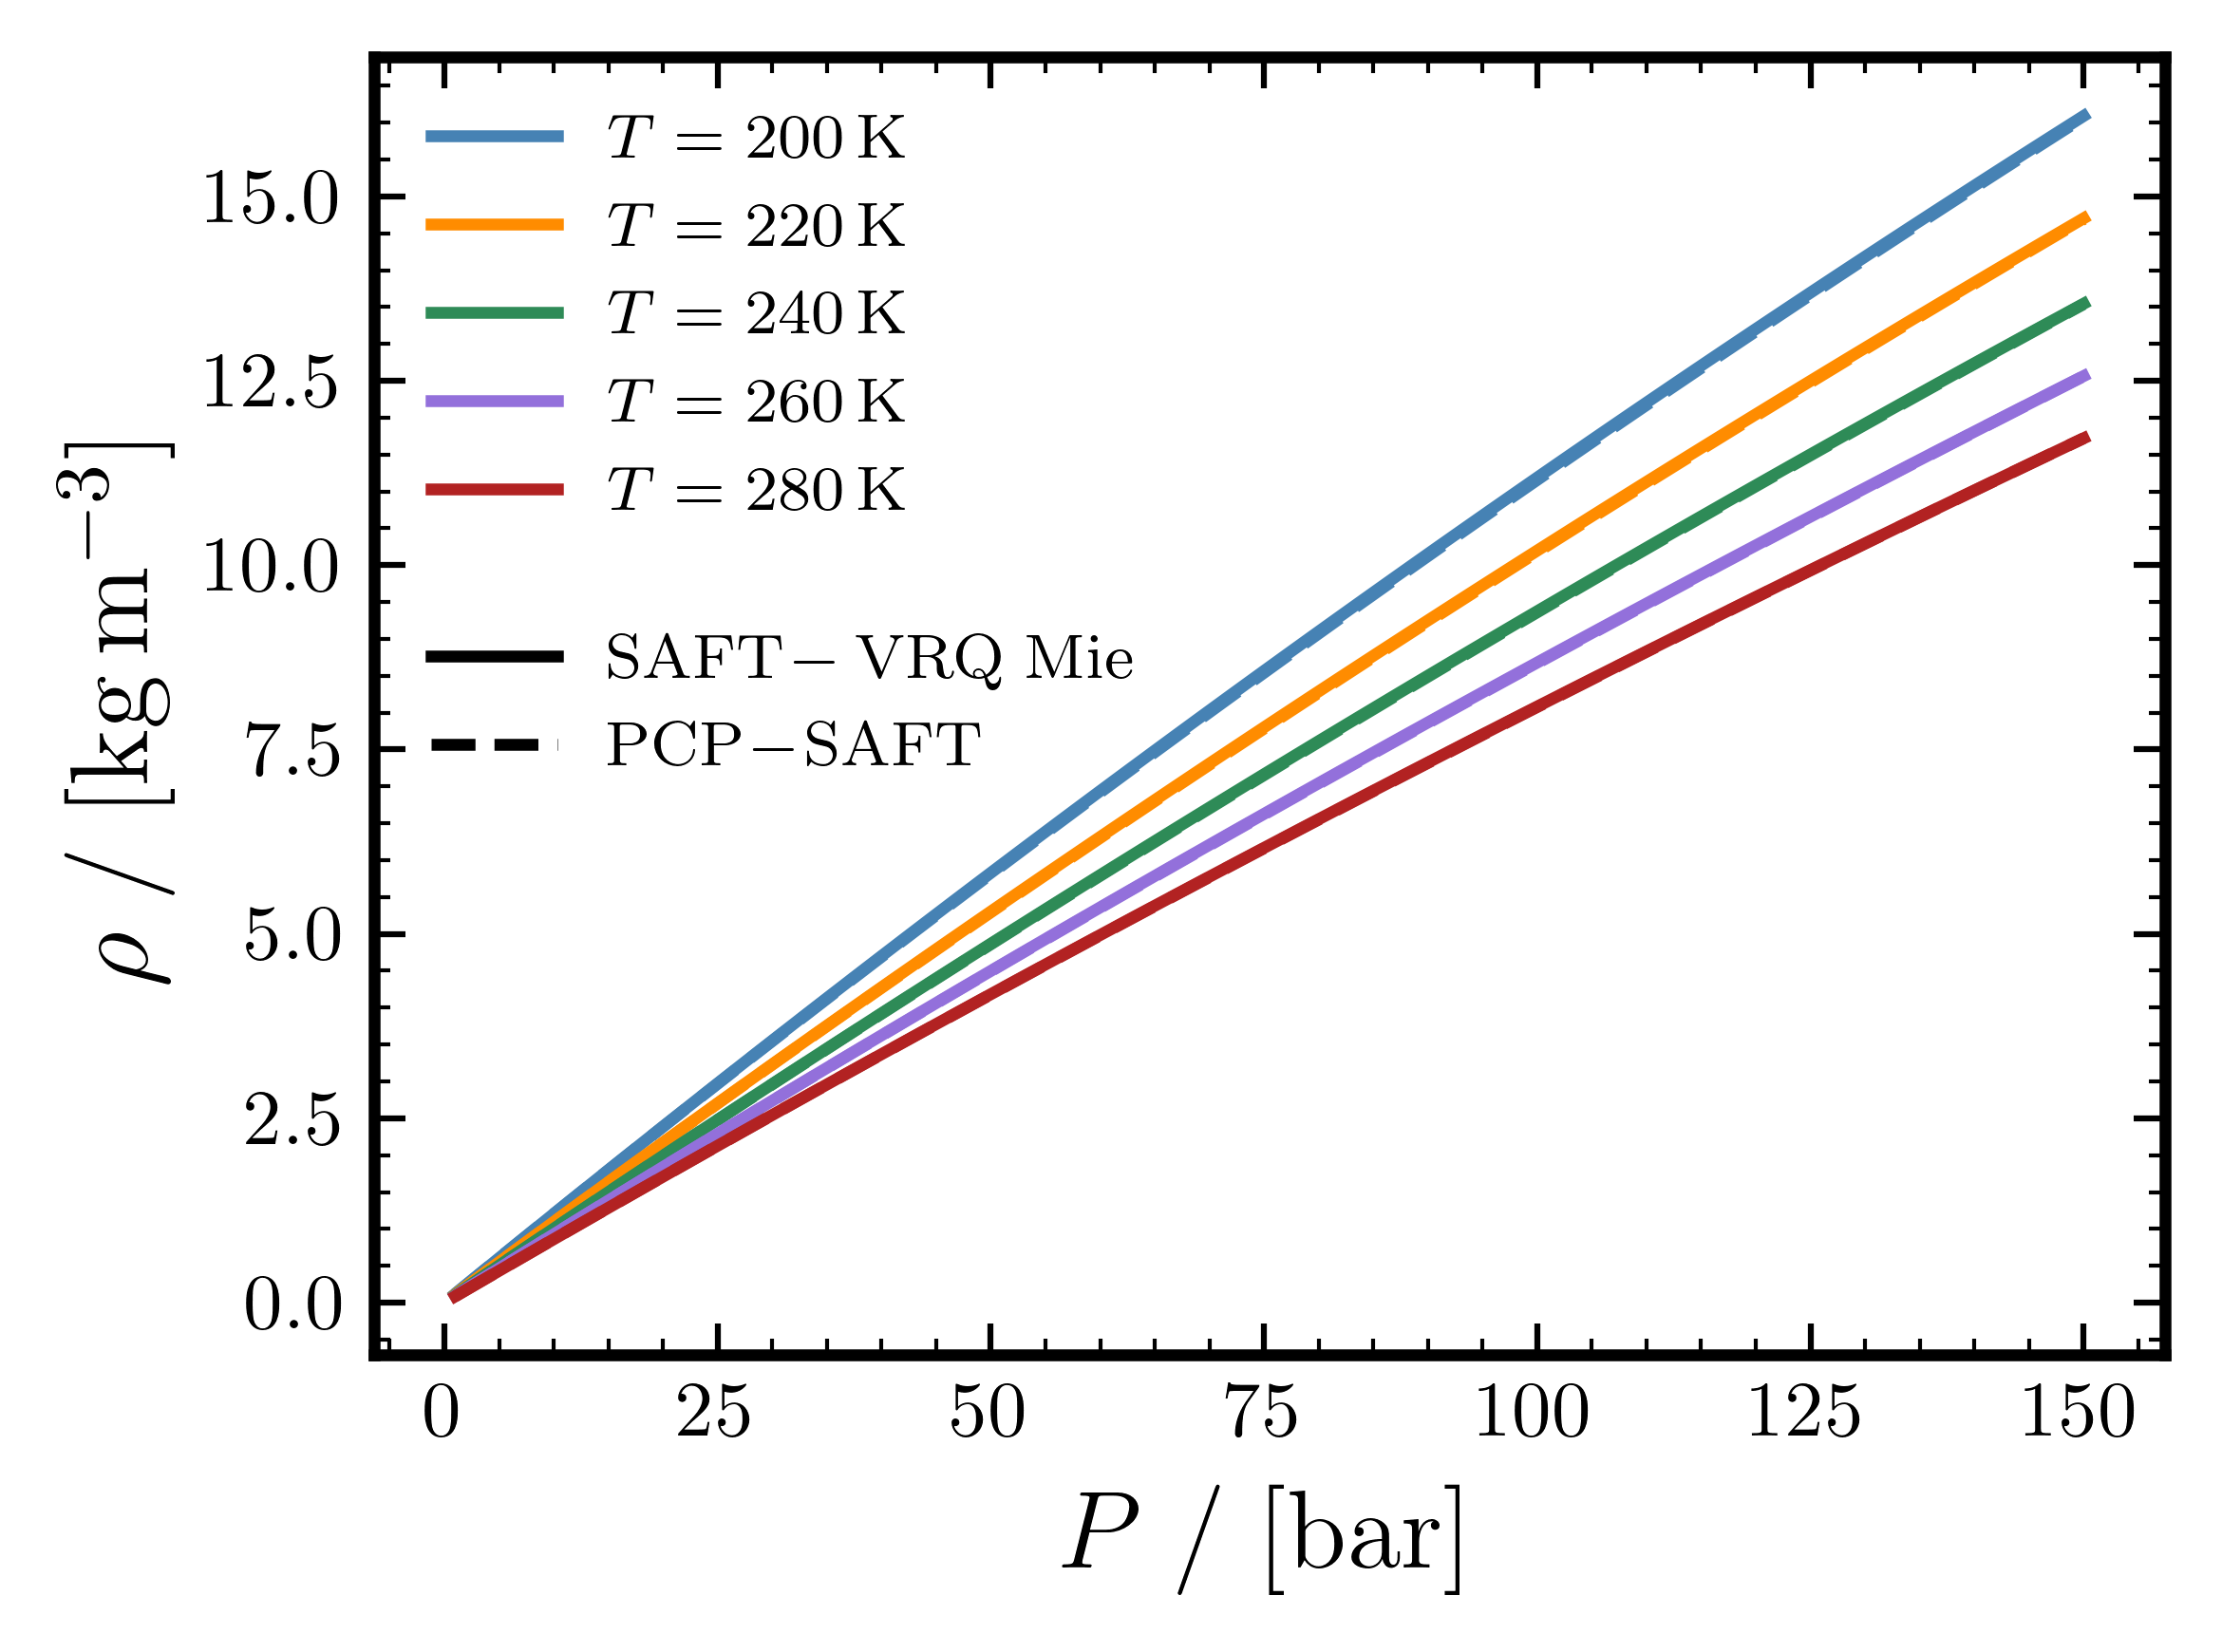

In [8]:
_colors = ['steelblue', 'darkorange', 'seagreen', 'mediumpurple', 'firebrick']

# ── Density ──────────────────────────────────────────────────────────────────
fig, ax = ps.plot_init()
for T_K, c in zip(T_compare, _colors):
    d = bulk[T_K]
    ax.plot(d['mie']['P'], d['mie']['rho'], '-',  color=c, lw=1.5,
            label=f'$T = {T_K}\\,\\mathrm{{K}}$')
    ax.plot(d['pc']['P'],  d['pc']['rho'],  '--', color=c, lw=1.5)

_leg_T   = ax.legend(loc='upper left', frameon=False, fontsize=ps.legend_fontsize)
_eos_lines = [Line2D([0],[0], color='k', lw=1.5, ls='-',  label=r'$\mathrm{SAFT\!-VRQ\;Mie}$'),
              Line2D([0],[0], color='k', lw=1.5, ls='--', label=r'$\mathrm{PCP\!-\!SAFT}$')]
ax.add_artist(_leg_T)
ax.legend(handles=_eos_lines, loc='center left', frameon=False, fontsize=ps.legend_fontsize)
ax.set_xlabel(r'$P\;/\;[\mathrm{bar}]$',                           fontsize=ps.label_fontsize)
ax.set_ylabel(r'$\rho\;/\;[\mathrm{kg\,m^{-3}}]$',              fontsize=ps.label_fontsize)
ax.minorticks_on()
plt.tight_layout()
plt.show()

# # ── Isobaric heat capacity ───────────────────────────────────────────────────
# fig, ax = ps.plot_init()
# for T_K, c in zip(T_compare, _colors):
#     d = bulk[T_K]
#     ax.plot(d['mie']['P'], d['mie']['cp'], '-',  color=c, lw=1.5,
#             label=f'$T = {T_K}\\,\\mathrm{{K}}$')
#     ax.plot(d['pc']['P'],  d['pc']['cp'],  '--', color=c, lw=1.5)

# _leg_T   = ax.legend(loc='upper right', frameon=False, fontsize=ps.legend_fontsize)
# ax.add_artist(_leg_T)
# ax.legend(handles=_eos_lines, loc='center right', frameon=False, fontsize=ps.legend_fontsize)
# ax.set_xlabel(r'$P\;/\;[\mathrm{bar}]$',                                      fontsize=ps.label_fontsize)
# ax.set_ylabel(r'$C_p\;/\;[\mathrm{J\,mol^{-1}\,K^{-1}}]$',                 fontsize=ps.label_fontsize)
# ax.minorticks_on()
# plt.tight_layout()
# plt.show()


---
## ⏸ Stop — Run `CO2.jl` Before Continuing

```bash
julia --threads auto H2.jl
```

Outputs written to `outputs/`:
- `hall_of_fame_gamma.jls` — serialised Pareto frontier (used by Part 2)
- `<timestamp>/hall_of_fame.csv` — equation table (read below)
- `equations_gamma.tex` / `.pdf` — LaTeX render

---
## Part 2 — Select Equation & Compare

In [9]:
import glob
import sympy as sp

# ── locate latest hall_of_fame.csv ──────────────────────────────────────────
_csvs = sorted(glob.glob("outputs/*/hall_of_fame.csv"))
assert _csvs, "No hall_of_fame.csv found - run CO2.jl first (Step 2)."
hof_path = _csvs[-1]
hof_df   = pd.read_csv(hof_path).reset_index(drop=True)

# ── sympy-based canonical extractor  σ = Σ sᵢ (1-Tr)^nᵢ ────────────────────
_F1 = sp.Symbol('F1', positive=True)

def _parse_sympy(eq_str):
    return eval(eq_str.strip(), {'__builtins__': {}},
                {'safepow': sp.Pow, 'F1': _F1})

def _extract_term(t):
    """(coeff, exp) if t = coeff * F1**n with numeric n, else None."""
    if not t.has(_F1):
        return (float(t), 0.0)
    if t is _F1:
        return (1.0, 1.0)
    if isinstance(t, sp.Pow) and t.base is _F1 and not t.exp.has(_F1):
        return (1.0, float(t.exp))
    if isinstance(t, sp.Mul):
        coeff, n_exp = sp.S.One, None
        for f in t.args:
            if not f.has(_F1):
                coeff *= f
            elif f is _F1:
                if n_exp is not None: return None
                n_exp = sp.S.One
            elif isinstance(f, sp.Pow) and f.base is _F1 and not f.exp.has(_F1):
                if n_exp is not None: return None
                n_exp = f.exp
            else:
                return None
        if n_exp is None: return None
        return (float(coeff), float(n_exp))
    return None

def extract_canonical(eq_str):
    """Returns sorted [(s, n), ...] or None if not expressible in canonical form."""
    try:
        expr = sp.expand(sp.simplify(_parse_sympy(eq_str)))
    except Exception:
        return None
    parts = expr.args if isinstance(expr, sp.Add) else [expr]
    result = [_extract_term(t) for t in parts]
    if any(r is None for r in result):
        return None
    return sorted(result, key=lambda x: -x[1])

def fmt_canonical(terms, sig=5):
    pieces = []
    for s, n in terms:
        ss = f"{s:.{sig}g}"
        if abs(n) < 1e-9:        pieces.append(ss)
        elif abs(n - 1) < 1e-9: pieces.append(f"{ss}*(1-Tr)")
        else:                    pieces.append(f"{ss}*(1-Tr)^{n:.{sig}g}")
    return "sigma = " + " + ".join(pieces)

def fmt_sympy(eq_str):
    """Sympy-simplified fallback — cleaner than the raw SR string."""
    try:
        expr = sp.simplify(_parse_sympy(eq_str))
        return str(expr).replace("F1", "(1-Tr)").replace("**", "^")
    except Exception:
        return eq_str

# ── display ──────────────────────────────────────────────────────────────────
print(f"SR run : {hof_path}\n")
print(f"{'#':<4} {'Cmplx':>5} {'RMSE':>12}   Canonical form  sigma = sum si*(1-T/Tc)^ni")
print("-" * 90)
for i, row in enumerate(hof_df.itertuples(index=False), 1):
    rmse = row.Loss ** 0.5
    canon = extract_canonical(row.Equation)
    label = fmt_canonical(canon) if canon is not None else "  " + fmt_sympy(row.Equation)
    print(f"{i:<4} {int(row.Complexity):>5} {rmse:>12.6g}   {label}")

SR run : outputs/20260515_171315_8IUKR6/hall_of_fame.csv

#    Cmplx         RMSE   Canonical form  sigma = sum si*(1-T/Tc)^ni
------------------------------------------------------------------------------------------
1        1     0.845718   sigma = 1.1537
2        3     0.138508   sigma = 5.3199*(1-Tr)
3        5   0.00247008   sigma = 7.0595*(1-Tr)^1.2702
4        7  0.000680152     7.03515696492713*((1-Tr) - 0.00248749981450744)^1.25764140191868
5        9  0.000277124   sigma = 8.4918*(1-Tr)^1.2072 + -1.51*(1-Tr)
6       11  0.000247531   sigma = 9.0593*(1-Tr)^1.193 + -2.0931*(1-Tr) + 0.010518*(1-Tr)^0.19301 + -0.00243
7       13  0.000149618   sigma = -0.50999*(1-Tr)^2 + 7.4539*(1-Tr)^1.2878 + -0.0030758
8       15  0.000140707     (7.85441223296839*(1-Tr)^1.27923537635998 - 0.00400566319011199)/((1-Tr)^1.27555254666104 + 2.09118094497456)^0.109793045827626
9       17  0.000140232     (7.86026818962973*((1-Tr) + 0.000185977300829916)^1.27971687380896 - 0.00460056885025708)/((1-T

In [10]:
best_idx = 7   # ← set this after reviewing the equation table above (1-indexed)

<>:26: SyntaxWarning: invalid escape sequence '\m'
<>:26: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_2912278/2673228693.py:26: SyntaxWarning: invalid escape sequence '\m'
  ax.set_xlabel("$\mathrm{Complexity}$",         fontsize=ps.label_fontsize)


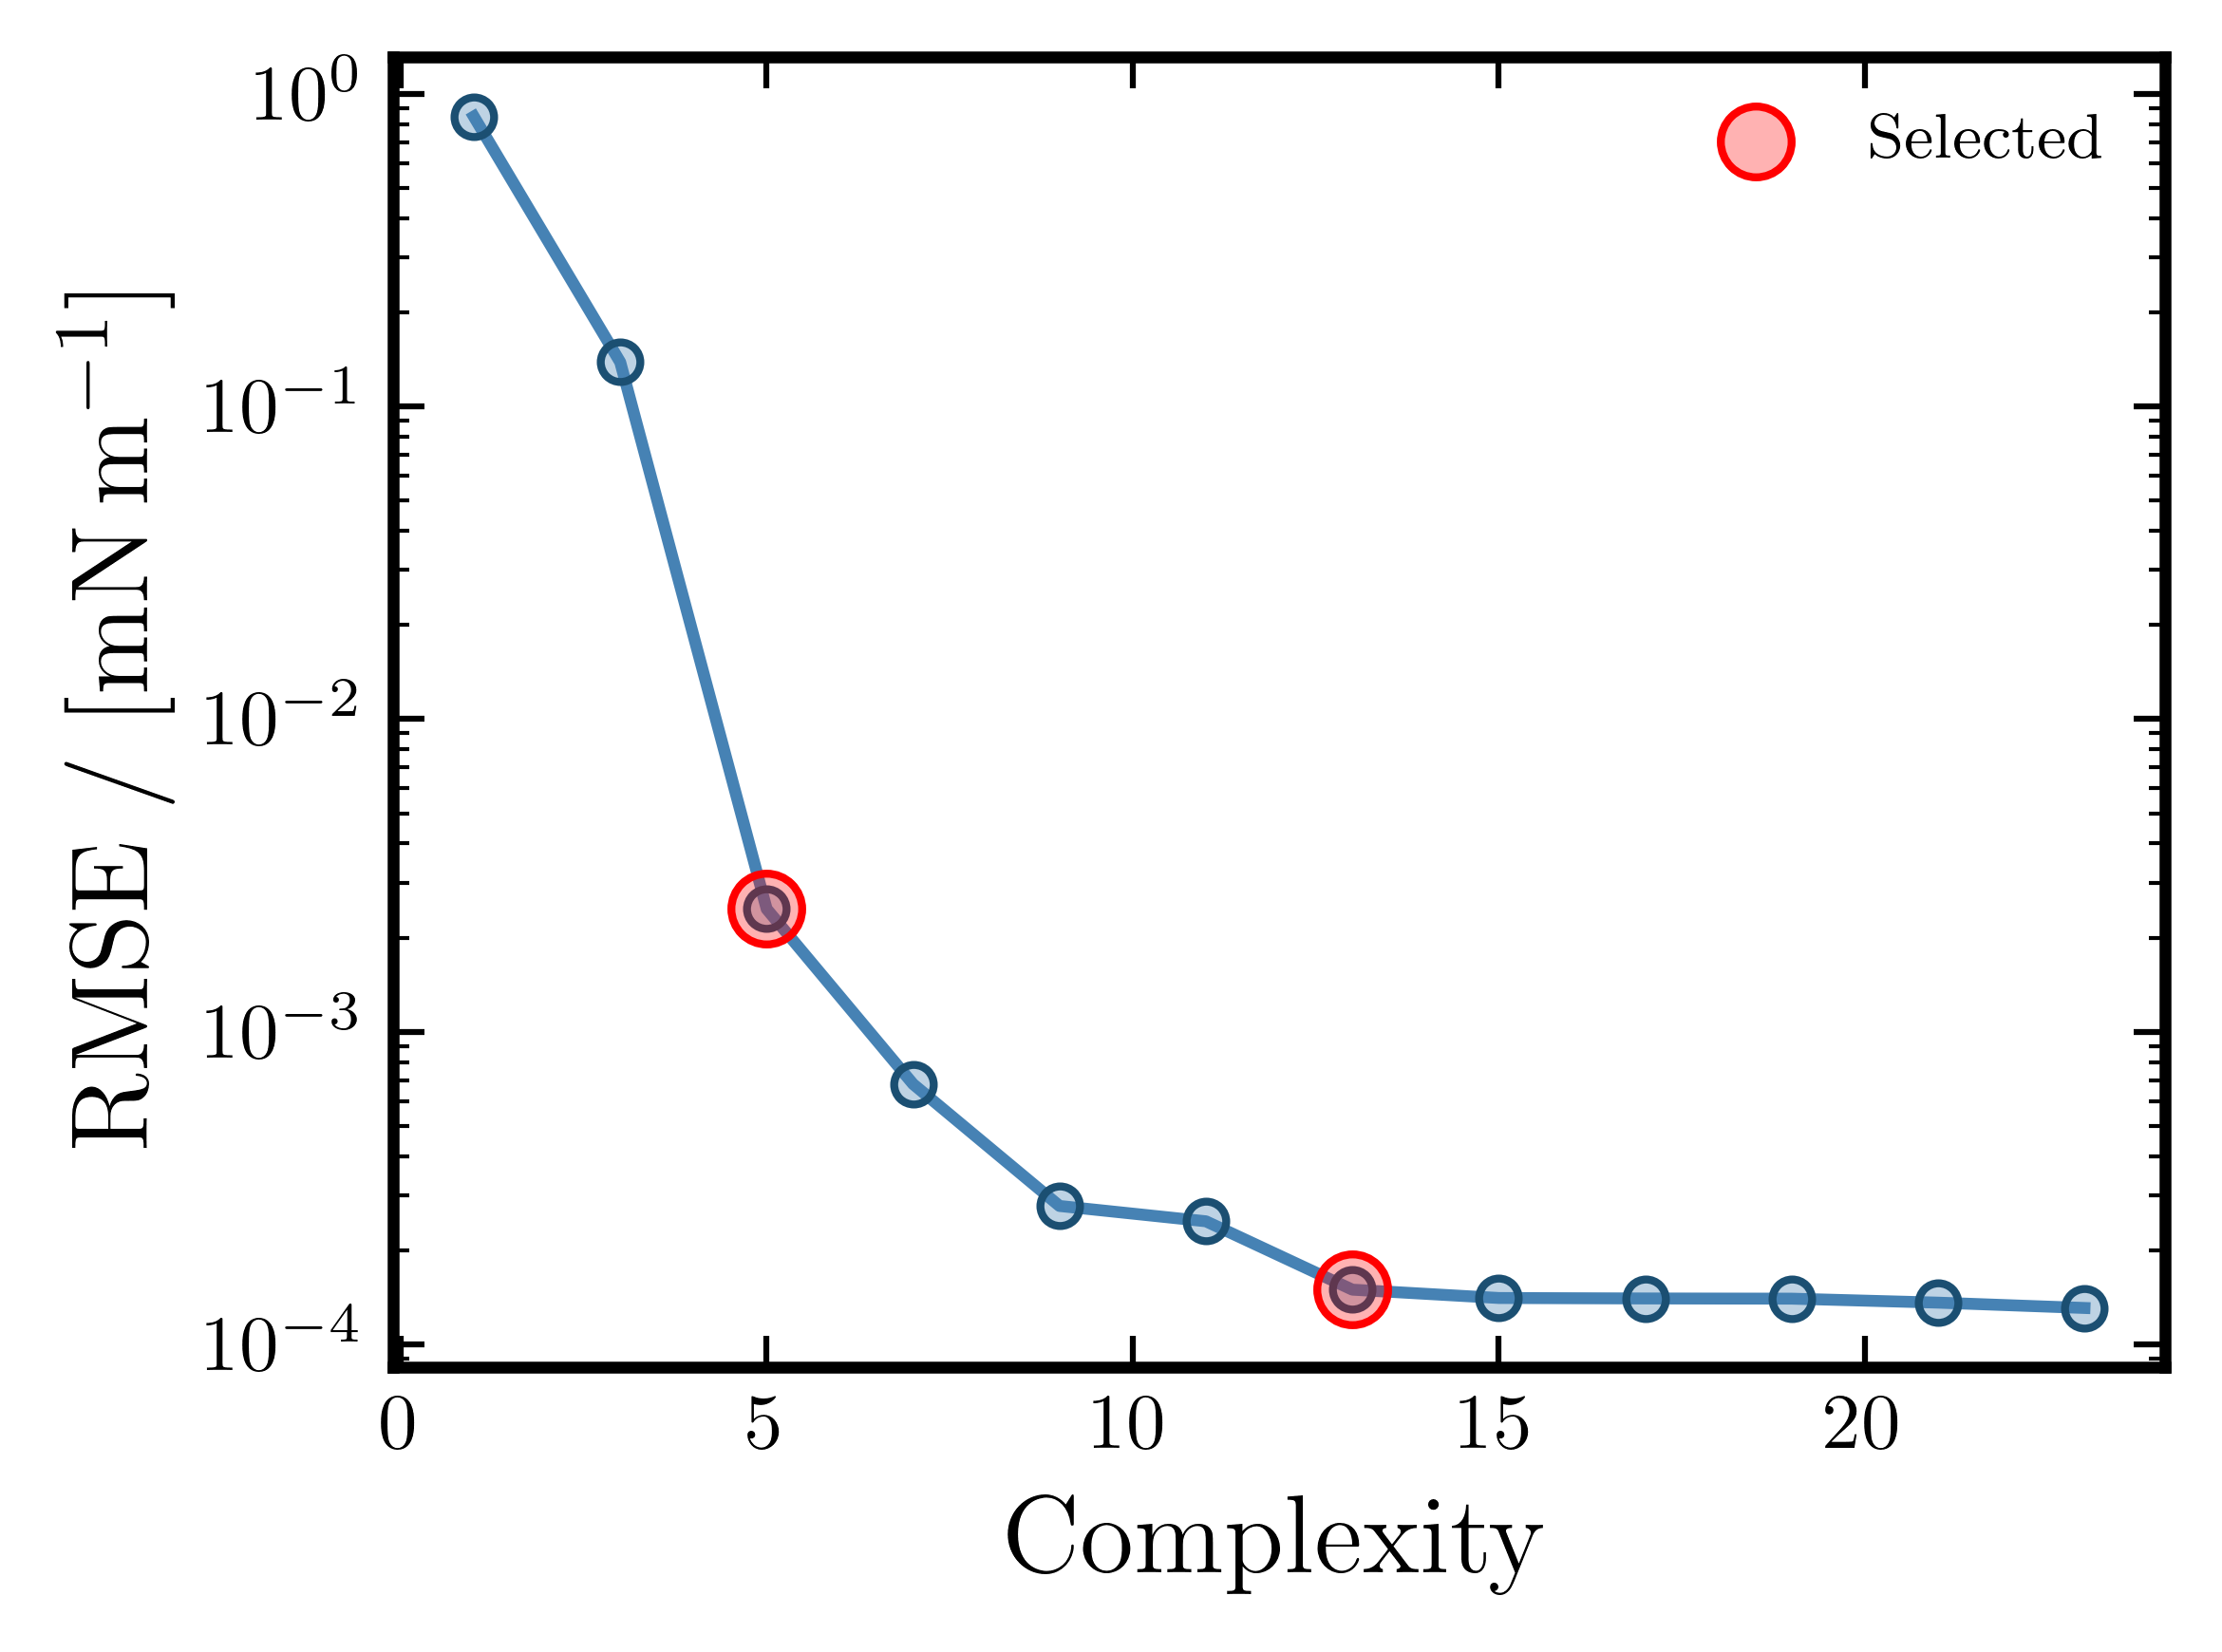

In [11]:
# ── Pareto front: complexity vs loss ────────────────────────────────────────

fig, ax = ps.plot_init()

complexities = hof_df["Complexity"].values
losses       = hof_df["Loss"].values ** 0.5

ax.plot(complexities, losses, "o-", color="steelblue",
        markeredgecolor="#1b4f72", markerfacecolor=(0.274, 0.510, 0.706, 0.35),
        markeredgewidth=1.0, markersize=5, lw=1.5)

# highlight the selected equation
ax.scatter(
    [hof_df.iloc[best_idx - 1]["Complexity"]],
    [hof_df.iloc[best_idx - 1]["Loss"] ** 0.5],
    facecolors=(1, 0, 0, 0.3), edgecolors="red",
    linewidths=1.0,zorder=5, s=80, label=f"$\\mathrm{{Selected}}$")

ax.scatter(
    [hof_df.iloc[3-1]["Complexity"]],
    [hof_df.iloc[3-1]["Loss"] ** 0.5],
    facecolors=(1, 0, 0, 0.3), edgecolors="red",
    linewidths=1.0,zorder=5, s=80)

ax.set_yscale("log")
ax.set_xlabel("$\mathrm{Complexity}$",         fontsize=ps.label_fontsize)
ax.set_ylabel(r"$\mathrm{RMSE} \; / \; [\mathrm{mN \, m^{-1}}]$",         fontsize=ps.label_fontsize)
# ax.set_title("Pareto Front — SR for pure CO2", fontsize=ps.title_fontsize)
ax.legend(frameon=False, fontsize=ps.legend_fontsize)
plt.tight_layout()
plt.show()

In [12]:
# ── print chosen equation ───────────────────────────────────────────────────
chosen  = hof_df.iloc[best_idx - 1]
eq_str  = chosen["Equation"]
canon   = extract_canonical(eq_str)
display = fmt_canonical(canon) if canon is not None else fmt_sympy(eq_str)
print(f"Equation {best_idx}  |  complexity = {int(chosen['Complexity'])}  |  RMSE = {chosen['Loss']**0.5:.6g}")
print(f"  sigma = {display}")

# ── evaluate over temperature grid ─────────────────────────────────────────
TC      = float(df["Tc"].iloc[0])
T_range = np.linspace(float(df["T_K"].min()), TC, 100, endpoint=False)
F1      = 1.0 - T_range / TC

def safepow(base, exp):
    b = np.asarray(base, float)
    return np.where(b >= 0, b ** np.asarray(exp, float), np.nan)

sigma = eval(eq_str, {"__builtins__": {}}, {"safepow": safepow, "F1": F1})

Equation 7  |  complexity = 13  |  RMSE = 0.000149618
  sigma = sigma = -0.50999*(1-Tr)^2 + 7.4539*(1-Tr)^1.2878 + -0.0030758


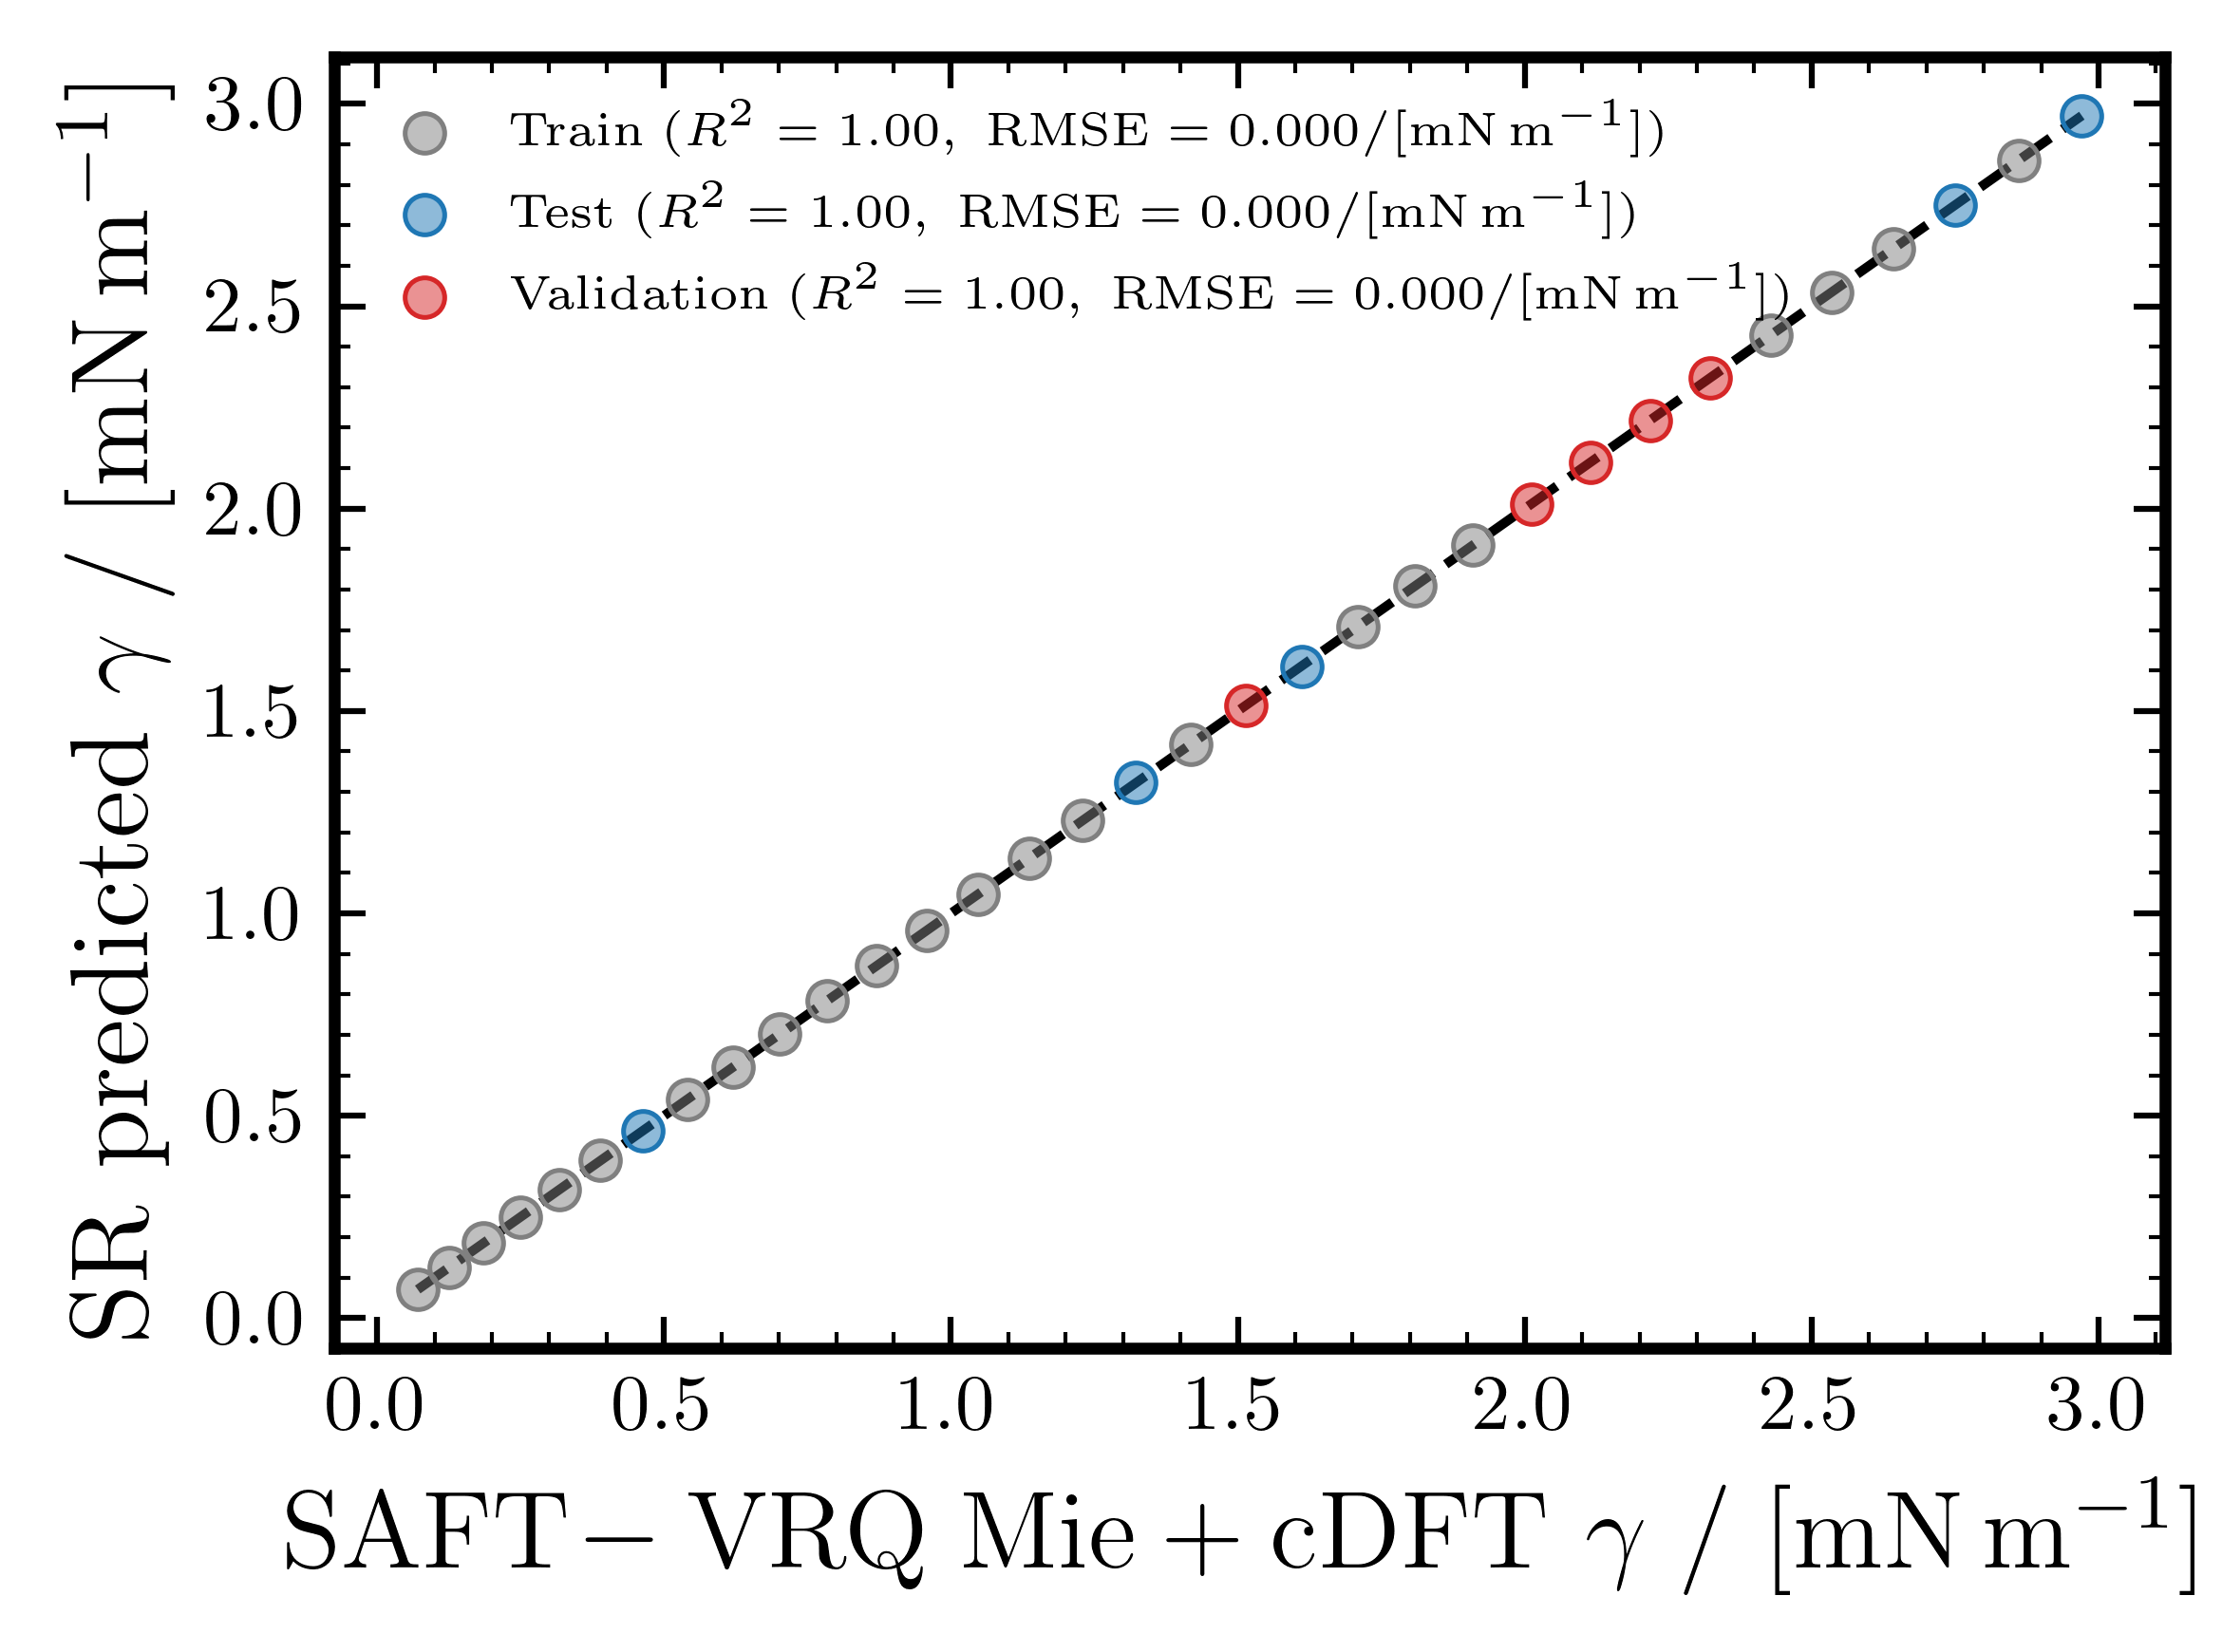

In [13]:
# ── Parity plot — train/val/test split from Julia indices ────────────────
# Requires outputs/split_indices.csv (written by CO2.jl)

def _r2(y, yh):
    ss_res = ((y - yh)**2).sum()
    ss_tot = ((y - y.mean())**2).sum()
    return 1 - ss_res / ss_tot

def _rmse(y, yh):
    return float(((y - yh)**2).mean()**0.5)

_TC      = float(df['Tc'].iloc[0])
_F1_full = 1.0 - df['T_K'].values / _TC
_y_full  = df['gamma'].values
_yh_full = eval(eq_str, {'__builtins__': {}}, {'safepow': safepow, 'F1': _F1_full})

# Load Julia split indices (1-based → 0-based); regenerate if stale
_n = len(_y_full)
_split_path = pathlib.Path('outputs/split_indices.csv')
_split_ok = False
if _split_path.exists():
    _split = pd.read_csv(_split_path)
    if _split['index'].max() - 1 < _n:   # all indices in bounds
        _split_ok = True
if not _split_ok:
    print(f'split_indices.csv missing or stale (n={_n}); regenerating with MersenneTwister seed 5002034')
    _rng = np.random.default_rng(5002034)
    _idx = _rng.permutation(_n)
    _n_tr  = round(0.70 * _n)
    _n_val = round(0.15 * _n)
    _split = pd.DataFrame({
        'index': _idx + 1,
        'split': ['train']*_n_tr + ['val']*_n_val + ['test']*(_n - _n_tr - _n_val)
    })
    pathlib.Path('outputs').mkdir(exist_ok=True)
    _split.to_csv(_split_path, index=False)
    print(f'  saved {len(_split)} rows to {_split_path}')
_tr_idx  = _split.loc[_split['split'] == 'train', 'index'].values - 1
_val_idx = _split.loc[_split['split'] == 'val',   'index'].values - 1
_te_idx  = _split.loc[_split['split'] == 'test',  'index'].values - 1

_y_tr,  _yh_tr  = _y_full[_tr_idx],  _yh_full[_tr_idx]
_y_val, _yh_val = _y_full[_val_idx], _yh_full[_val_idx]
_y_te,  _yh_te  = _y_full[_te_idx],  _yh_full[_te_idx]

r2_tr,  rmse_tr  = _r2(_y_tr,  _yh_tr),  _rmse(_y_tr,  _yh_tr)
r2_val, rmse_val = _r2(_y_val, _yh_val), _rmse(_y_val, _yh_val)
r2_te,  rmse_te  = _r2(_y_te,  _yh_te),  _rmse(_y_te,  _yh_te)

_lo, _hi = _y_full.min(), _y_full.max()

fig, ax = ps.plot_init()
ax.scatter(_y_tr,  _yh_tr,  s=25,
           facecolors=(0.5, 0.5, 0.5, 0.5),           edgecolors='gray',     linewidths=0.6,
           zorder=3, label=f'$\\mathrm{{Train}}\\ (R^2={r2_tr:.2f},\\ \\mathrm{{RMSE}}={rmse_tr:.3f} / [\\mathrm{{mN\\,m^{{-1}}}}])$')
ax.scatter(_y_te,  _yh_te,  s=25,
           facecolors=(0.122, 0.467, 0.706, 0.5),     edgecolors='#1f77b4',  linewidths=0.6,
           zorder=3, label=f'$\\mathrm{{Test}}\\ (R^2={r2_te:.2f},\\ \\mathrm{{RMSE}}={rmse_te:.3f} / [\\mathrm{{mN\\,m^{{-1}}}}])$')
ax.scatter(_y_val, _yh_val, s=25,
           facecolors=(0.839, 0.153, 0.157, 0.5),     edgecolors='#d62728',  linewidths=0.6,
           zorder=3, label=f'$\\mathrm{{Validation}}\\ (R^2={r2_val:.2f},\\ \\mathrm{{RMSE}}={rmse_val:.3f} / [\\mathrm{{mN\\,m^{{-1}}}}])$')

ax.plot([_lo, _hi], [_lo, _hi], 'k--', lw=1.2)
ax.set_xlabel(r"$\mathrm{SAFT\!-VRQ\;Mie+cDFT}\ \gamma \; / \; [\mathrm{mN \, m^{-1}}]$", fontsize=ps.label_fontsize)
ax.set_ylabel(r"$\mathrm{SR\ predicted}\ \gamma \; / \; [\mathrm{mN \, m^{-1}}]$", fontsize=ps.label_fontsize)
# ax.set_title(f'Parity Plot - SR Eq.{best_idx}',   fontsize=ps.title_fontsize)
ax.legend(loc='upper left', fontsize=ps.legend_fontsize*0.75, frameon=False)
ax.minorticks_on()
plt.tight_layout()
plt.show()


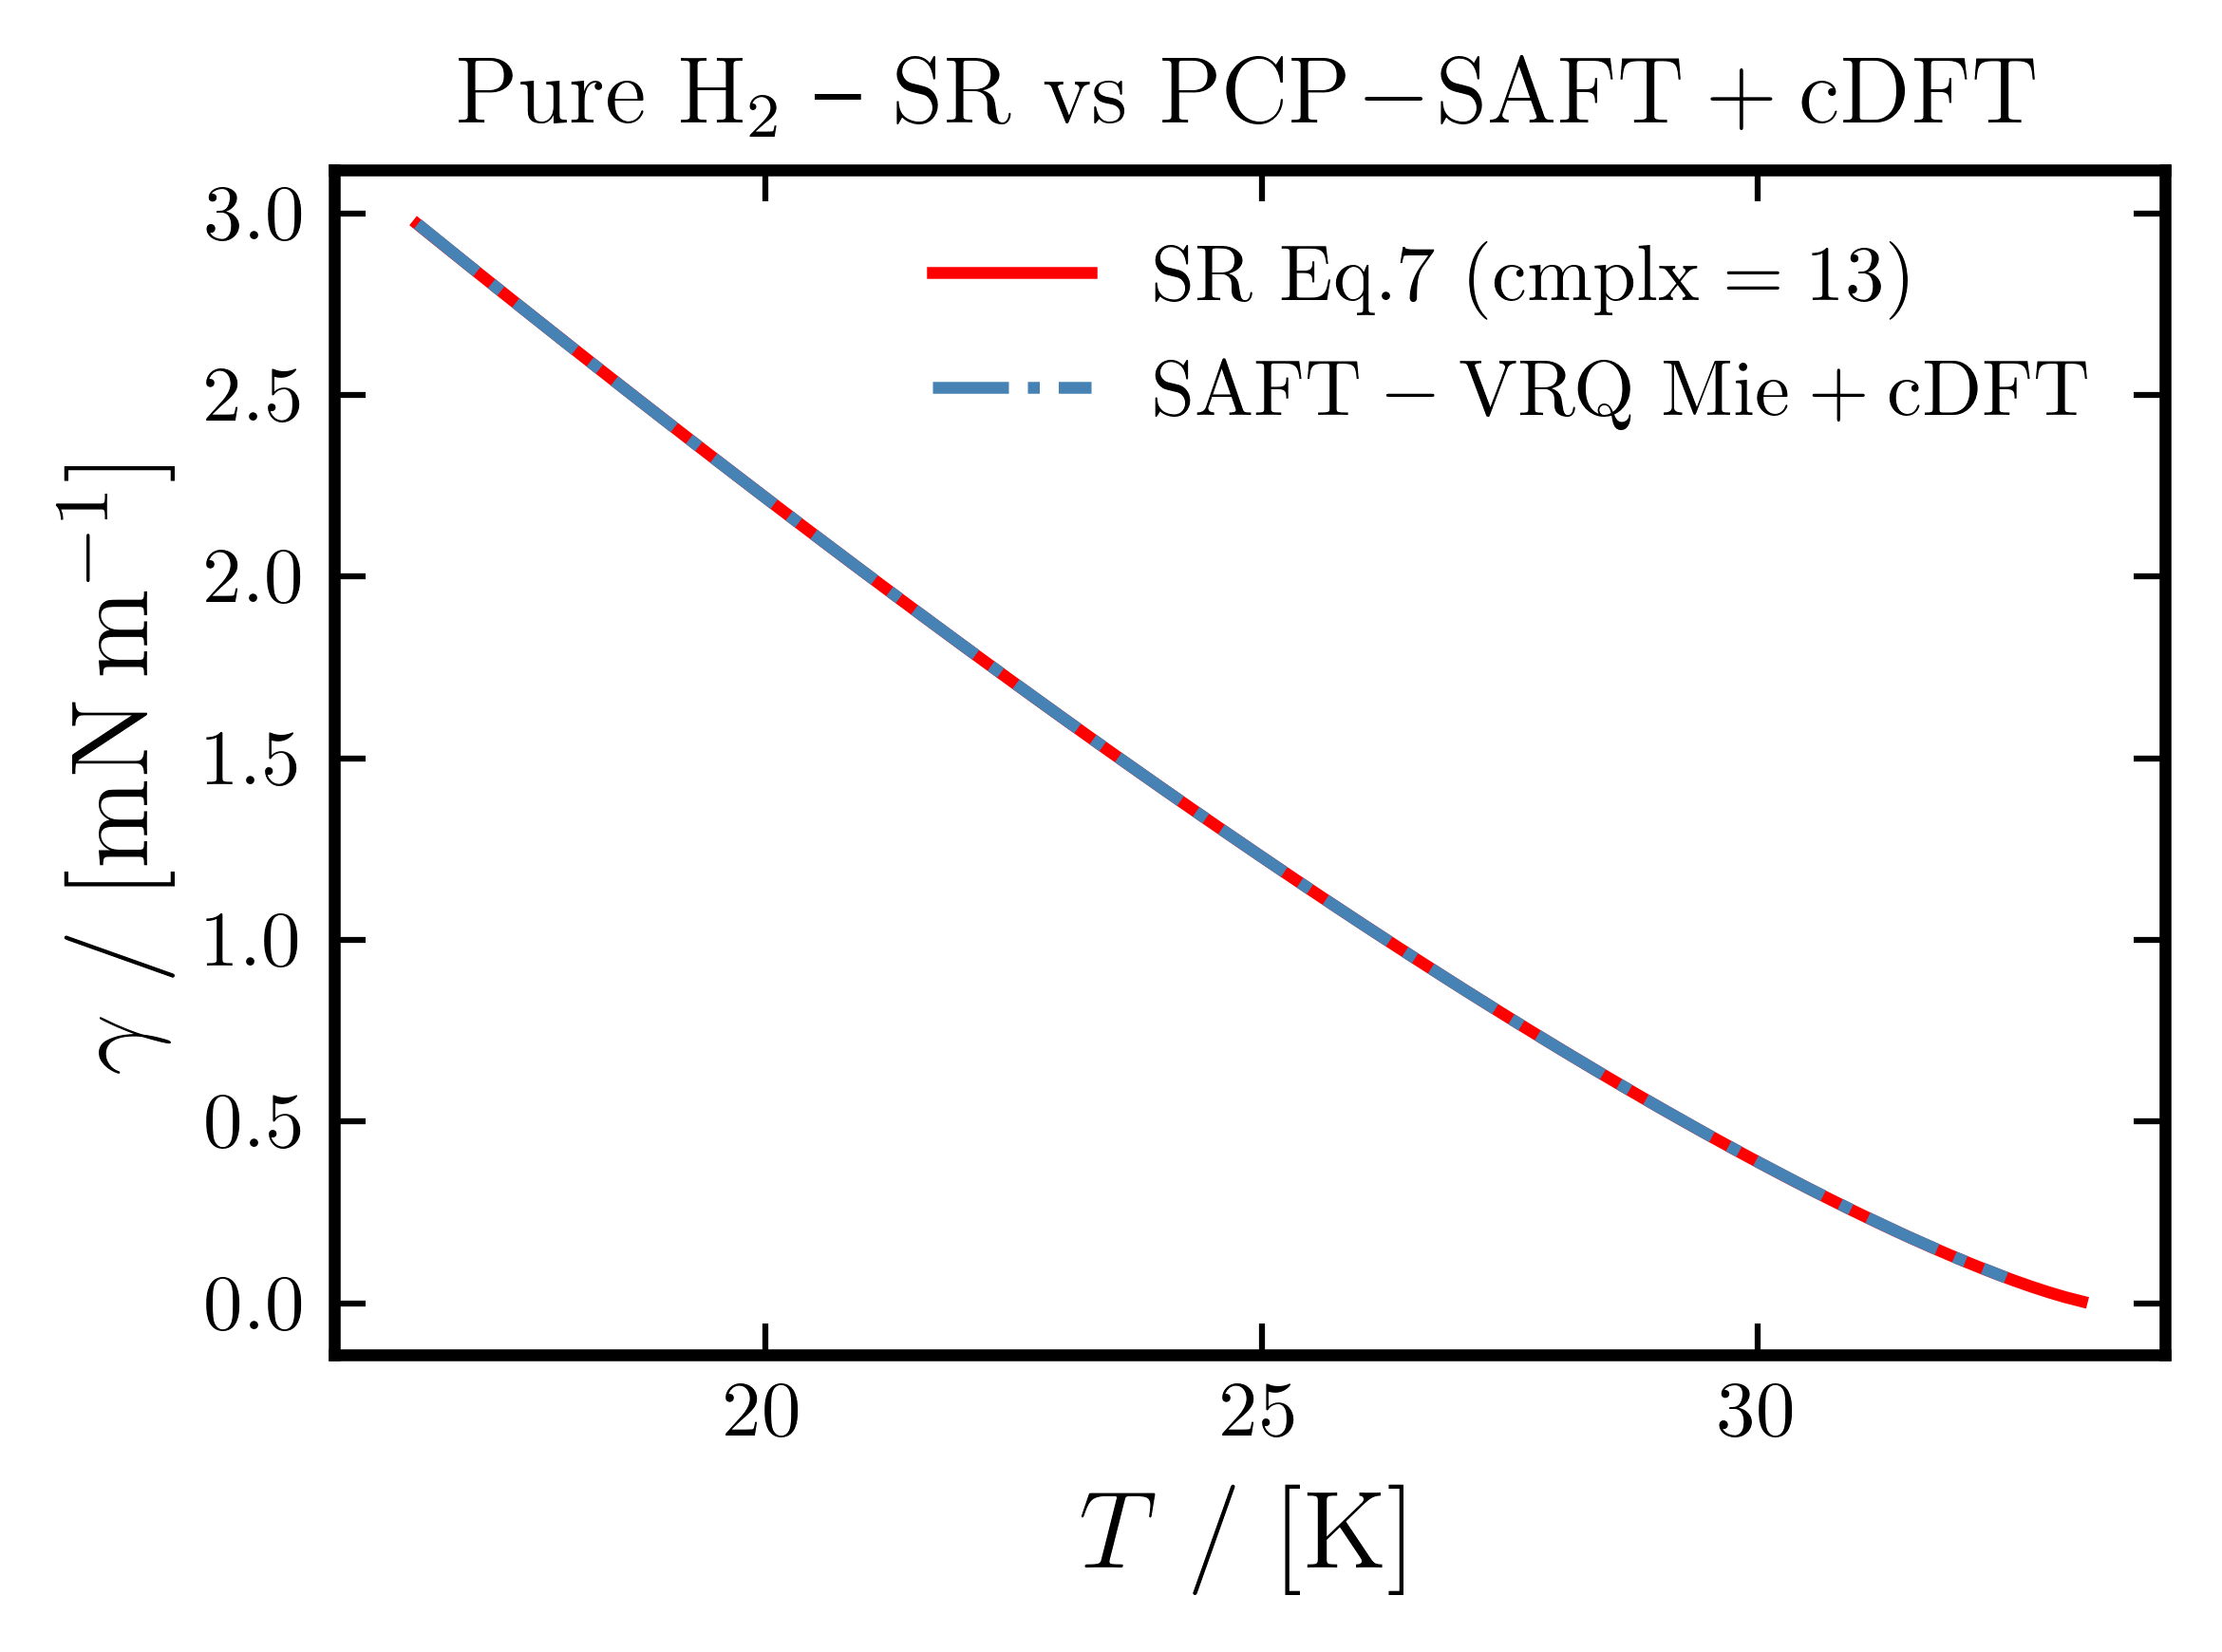

In [14]:
fig, ax = ps.plot_init()
ax.plot(T_range, sigma, "-",  markersize=4, color="red",       label=f"$\\mathrm{{SR\\ Eq.}}{best_idx}\\ (\\mathrm{{cmplx}}={int(chosen['Complexity'])})$")
ax.plot(df['T_K'], df['gamma'], "-.", markersize=4, color="steelblue", label=r"$\mathrm{SAFT-VRQ\ Mie+cDFT}$")
ax.set_xlabel(r"$T \; / \; [\mathrm{K}]$",fontsize=ps.label_fontsize)
ax.set_ylabel(r"$\gamma \; / \; [\mathrm{mN \, m^{-1}}]$",fontsize=ps.label_fontsize)
ax.set_title(r"$\mathrm{Pure\ H_{2}}$ -- $\mathrm{SR\ vs\ PCP\!-\!SAFT+cDFT}$", fontsize=ps.title_fontsize)
ax.legend(loc='best', frameon=False)
plt.tight_layout()
plt.show()

In [15]:
# Compute pure surface tension using InterfacialTension from Interfacethermopy

ift = InterfacialTension('Mulero_2012.json')
rp_path = "/home/darshan/Software/REFPROP/REFPROP-cmake/build"
ift.ctREFPROP_init(rp_path)
fluid_name = "hydrogen"
T_range_pure = np.arange(15, 33, 1)   # Mulero valid up to real Tc = 33.145 K

gamma_pure = []
for T in T_range_pure:
    gamma_T, T_used = ift.compute_gamma_pure(T, fluid_name, key='Parachor')
    gamma_pure.append(gamma_T)

gamma_pure = np.array(gamma_pure)

REFPROP version = 10.0
GERG-2008 model = Disabled


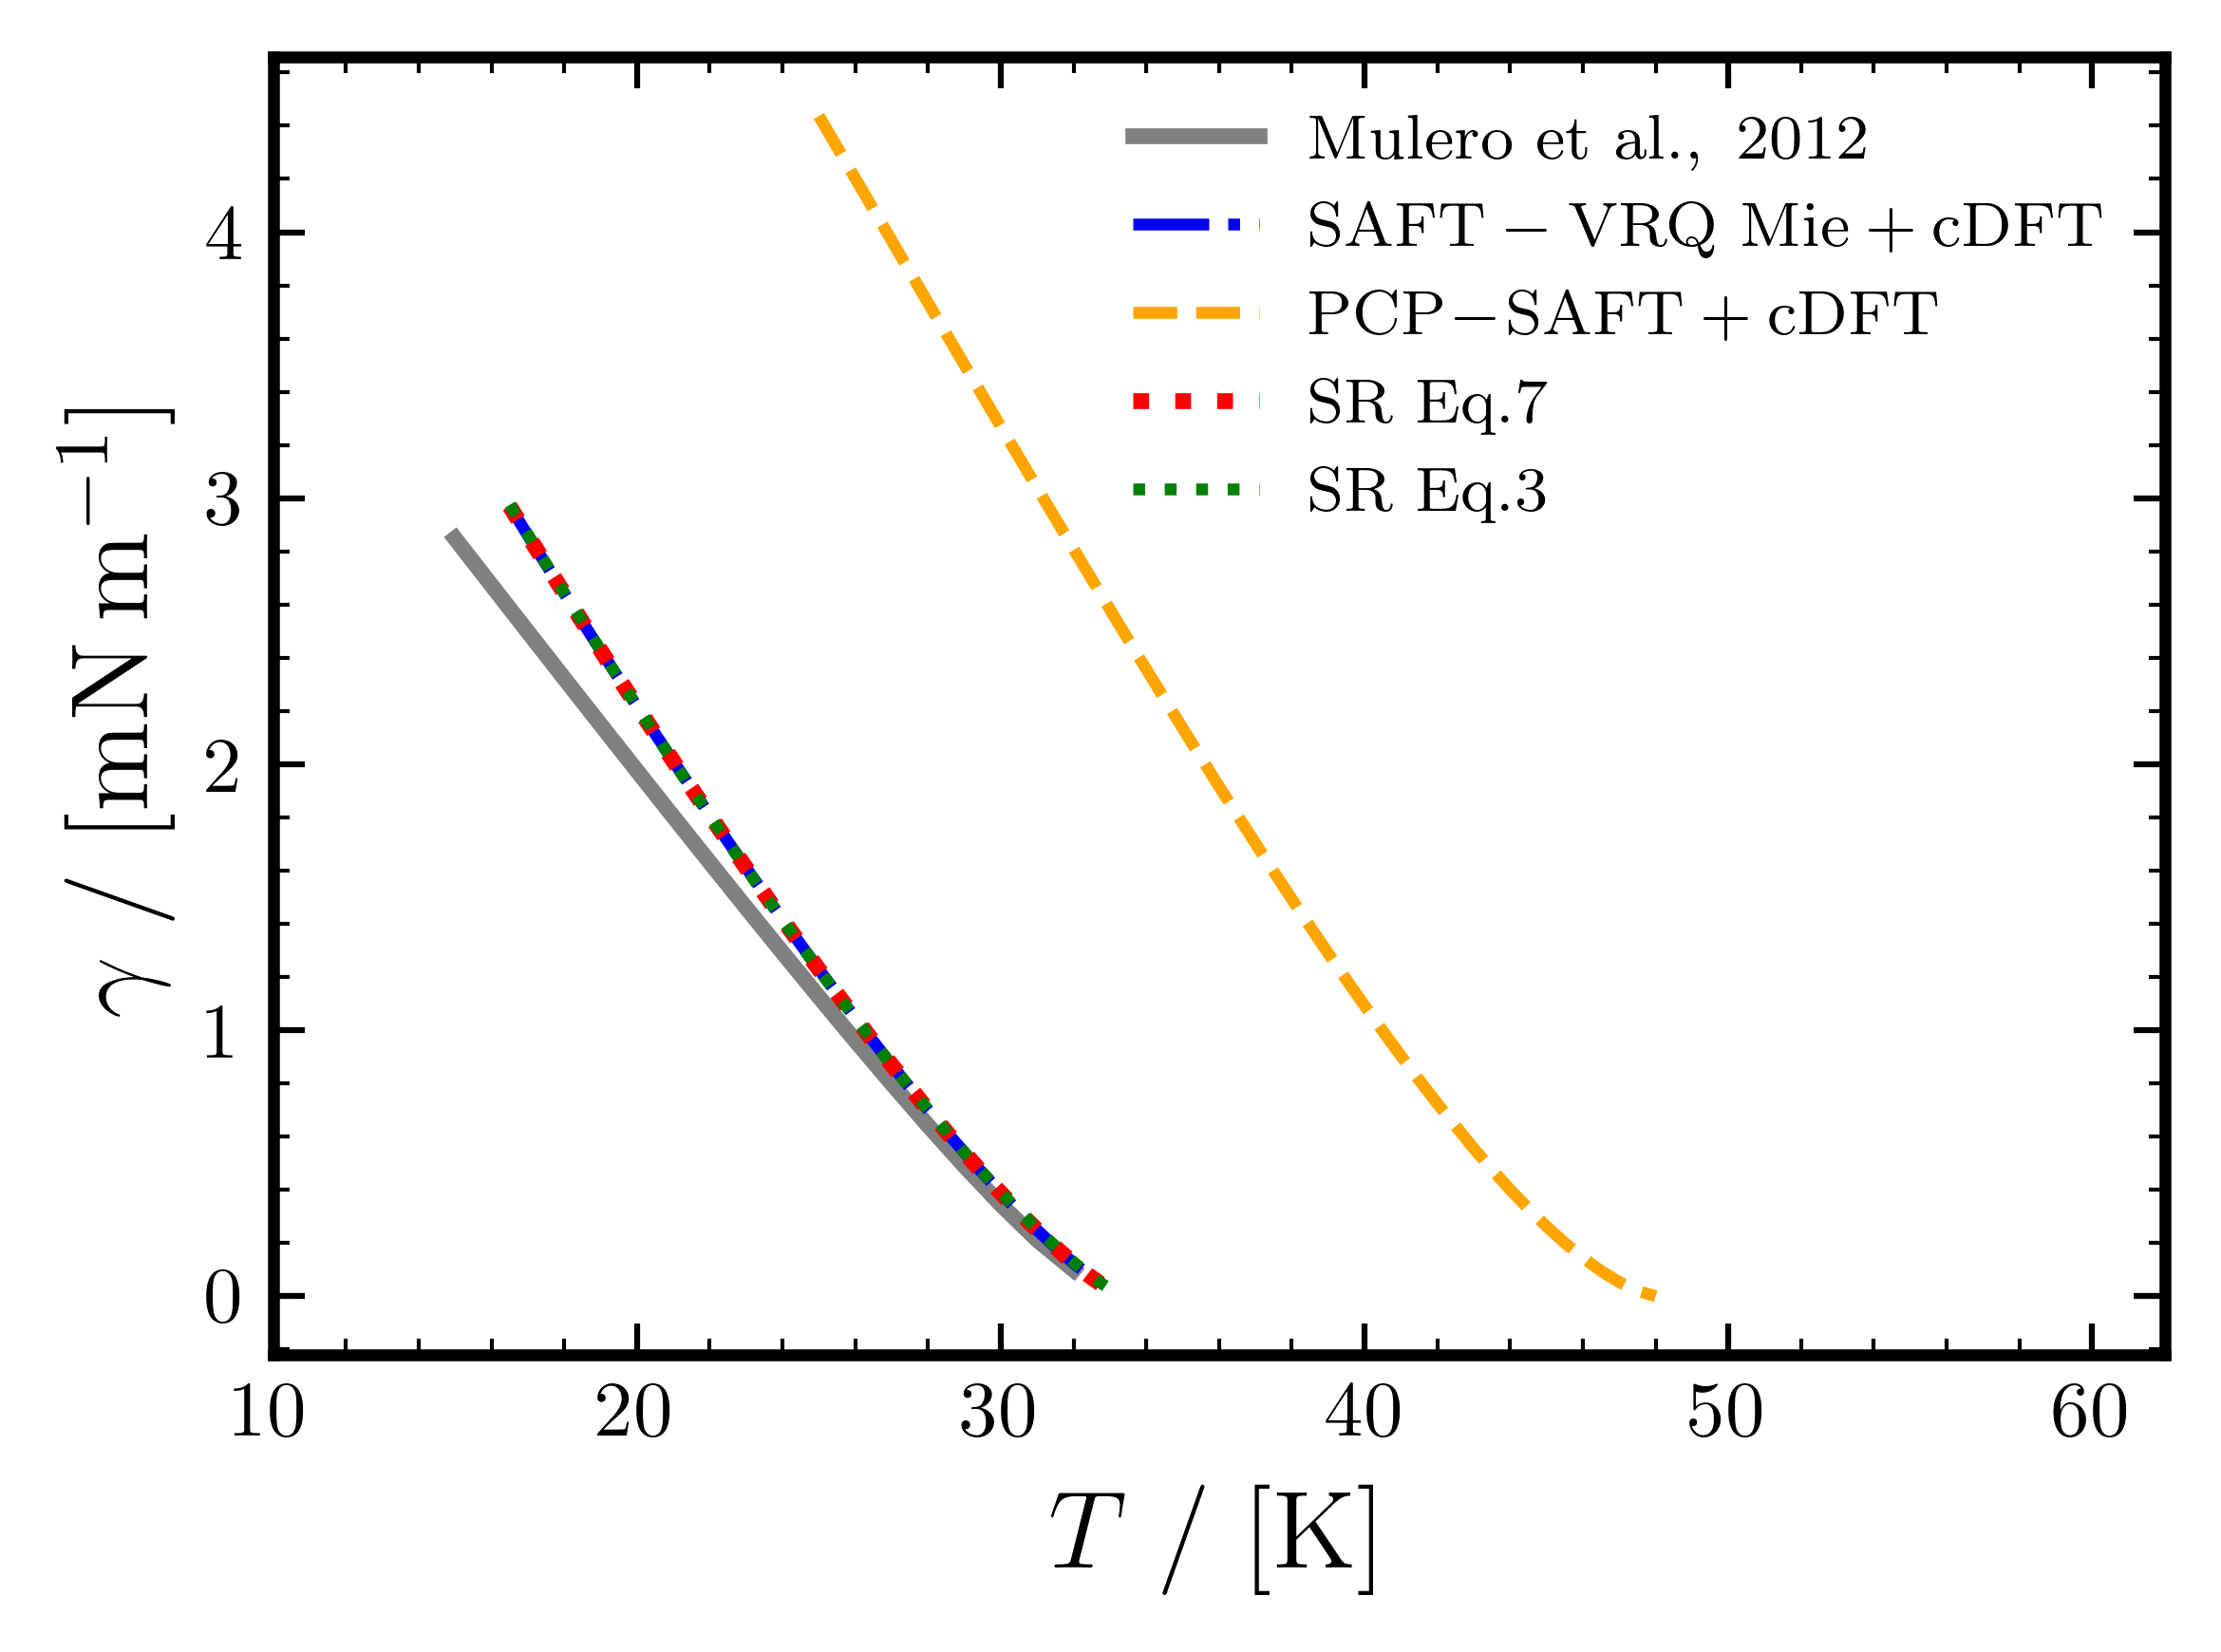

In [16]:
# Plot comparison
_eq3_str = hof_df.iloc[2]["Equation"]
_sigma3  = eval(_eq3_str, {"__builtins__": {}}, {"safepow": safepow, "F1": F1})

fig, ax = ps.plot_init()
ax.plot(T_range_pure, gamma_pure,  "-",  lw=2,        color="grey",    label=r"$\mathrm{Mulero\ et\ al.,\ 2012}$")
ax.plot(df['T_K'],    df['gamma'], "-.", markersize=4, color="blue",     label=r"$\mathrm{SAFT-VRQ\ Mie+cDFT}$")
ax.plot(df_pcsaft['T_K'], df_pcsaft['gamma'], '--', markersize=4, color='orange', label=r"$\mathrm{PCP\!-\!SAFT+cDFT}$")
ax.plot(T_range,      sigma,       ":",  lw=2,         color="red",      label=f"$\\mathrm{{SR\\ Eq.{best_idx}}}$")
ax.plot(T_range,      _sigma3,     ":",  lw=1.5,       color="green",   label=r"$\mathrm{SR\ Eq.3}$")
ax.set_xlabel(r"$T \; / \; [\mathrm{K}]$",               fontsize=ps.label_fontsize)
ax.set_ylabel(r"$\gamma \; / \; [\mathrm{mN \, m^{-1}}]$", fontsize=ps.label_fontsize)
ax.legend(loc='best', fontsize=ps.legend_fontsize, frameon=False)
plt.xlim(T_range_pure.min()-5, T_range_pure.max()+30)
ax.minorticks_on()
plt.tight_layout()
plt.show()